In [1]:
import os
path = os.getenv('DATA_PATH')
token = os.getenv('API_TOKEN')

In [2]:
from a3em_analysis.datasets import Arden
arden = Arden(path, token)
X_train, X_test, y_train, y_test = arden.load_data_ml(random_state=123, shuffle=True) 

prefetch complete
extracting features


100%|██████████| 62/62 [02:26<00:00,  2.36s/it]


In [3]:
X_train.head()

,peak_freq,centroid,bandwidth,freq_5,freq_95,hnr,hnr_low,mfcc_1,mfcc_2,mfcc_3,...,mel_mean_17,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26
169,38.085938,270.605384,159.290492,44.921875,499.023438,-8.143899,0.375138,-219.055023,231.848453,-106.179115,...,0.024150,0.010053,0.002243,0.000471,0.000045,1.056747e-05,3.717823e-06,1.061319e-06,6.991659e-07,6.892982e-07
1319,40.039062,203.006208,152.065297,35.156250,413.085938,-4.896778,-4.133177,-319.261811,239.756249,-67.216690,...,0.001718,0.000326,0.000049,0.000019,0.000004,4.775796e-07,4.968244e-08,1.847422e-08,1.456388e-08,1.343114e-08
778,32.226562,221.089798,160.524293,29.296875,415.039062,-1.618809,-2.119384,-135.172643,241.908465,-86.546979,...,0.043731,0.010725,0.003043,0.001301,0.000620,4.088144e-04,3.626983e-04,3.541892e-04,3.507193e-04,3.491860e-04
680,59.570312,246.475124,153.750402,41.015625,455.078125,0.040098,1.430227,-109.089317,256.002013,-107.424887,...,0.087319,0.021591,0.005770,0.001862,0.000688,4.025324e-04,3.501236e-04,3.276134e-04,3.171824e-04,3.115223e-04
185,37.109375,147.331787,118.940215,35.156250,116.210938,-4.528715,-0.312973,-233.802362,225.681163,-13.118166,...,0.001388,0.000261,0.000056,0.000013,0.000004,1.446409e-06,1.032583e-06,9.858418e-07,9.733421e-07,9.679911e-07


In [4]:
y_train.head()

169     0
1319    1
778     0
680     0
185     1
Name: label, dtype: int64

## Analysis

In [5]:
import pandas as pd

In [6]:
train_features = X_train
test_feature = X_test
train_labels = y_train
test_labels = y_test

features_aggregate = pd.concat([train_features, test_feature], ignore_index=True)
labels_aggregate = pd.concat([train_labels, test_labels], ignore_index=True)

In [7]:
labels_aggregate.value_counts()

label
0    1058
1     705
Name: count, dtype: int64

In [8]:
# Combine
df = train_features.copy()
df['label'] = train_labels

In [9]:
df.head()

,peak_freq,centroid,bandwidth,freq_5,freq_95,hnr,hnr_low,mfcc_1,mfcc_2,mfcc_3,...,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26,label
169,38.085938,270.605384,159.290492,44.921875,499.023438,-8.143899,0.375138,-219.055023,231.848453,-106.179115,...,0.010053,0.002243,0.000471,0.000045,1.056747e-05,3.717823e-06,1.061319e-06,6.991659e-07,6.892982e-07,0
1319,40.039062,203.006208,152.065297,35.156250,413.085938,-4.896778,-4.133177,-319.261811,239.756249,-67.216690,...,0.000326,0.000049,0.000019,0.000004,4.775796e-07,4.968244e-08,1.847422e-08,1.456388e-08,1.343114e-08,1
778,32.226562,221.089798,160.524293,29.296875,415.039062,-1.618809,-2.119384,-135.172643,241.908465,-86.546979,...,0.010725,0.003043,0.001301,0.000620,4.088144e-04,3.626983e-04,3.541892e-04,3.507193e-04,3.491860e-04,0
680,59.570312,246.475124,153.750402,41.015625,455.078125,0.040098,1.430227,-109.089317,256.002013,-107.424887,...,0.021591,0.005770,0.001862,0.000688,4.025324e-04,3.501236e-04,3.276134e-04,3.171824e-04,3.115223e-04,0
185,37.109375,147.331787,118.940215,35.156250,116.210938,-4.528715,-0.312973,-233.802362,225.681163,-13.118166,...,0.000261,0.000056,0.000013,0.000004,1.446409e-06,1.032583e-06,9.858418e-07,9.733421e-07,9.679911e-07,1


### Compute Summary Statistics

In [10]:
summary = df.groupby("label").mean()

std_summary = df.groupby("label").std()

comparison = pd.DataFrame({
    "Background Mean": df[df["label"] == 0].mean(),
    "Rumble Mean": df[df["label"] == 1].mean(),
    "Background Std": df[df["label"] == 0].std(),
    "Rumble Std": df[df["label"] == 1].std()
})

comparison = comparison.drop(index="label")
comparison

,Background Mean,Rumble Mean,Background Std,Rumble Std
peak_freq,42.830239,36.139654,7.961705,8.687774
centroid,226.963924,173.539248,42.734426,22.349894
bandwidth,147.761405,134.247787,13.183124,9.960800
freq_5,41.315927,36.912694,18.627430,8.934612
freq_95,385.853928,180.079151,112.049373,86.866050
hnr,-8.298023,-3.030975,6.222722,3.950538
hnr_low,-6.629839,-0.274716,6.895740,4.092804
mfcc_1,-217.700757,-229.461177,82.472313,40.637253
mfcc_2,240.967398,234.214048,17.239061,10.199334
mfcc_3,-81.964981,-37.597484,34.373616,18.142096


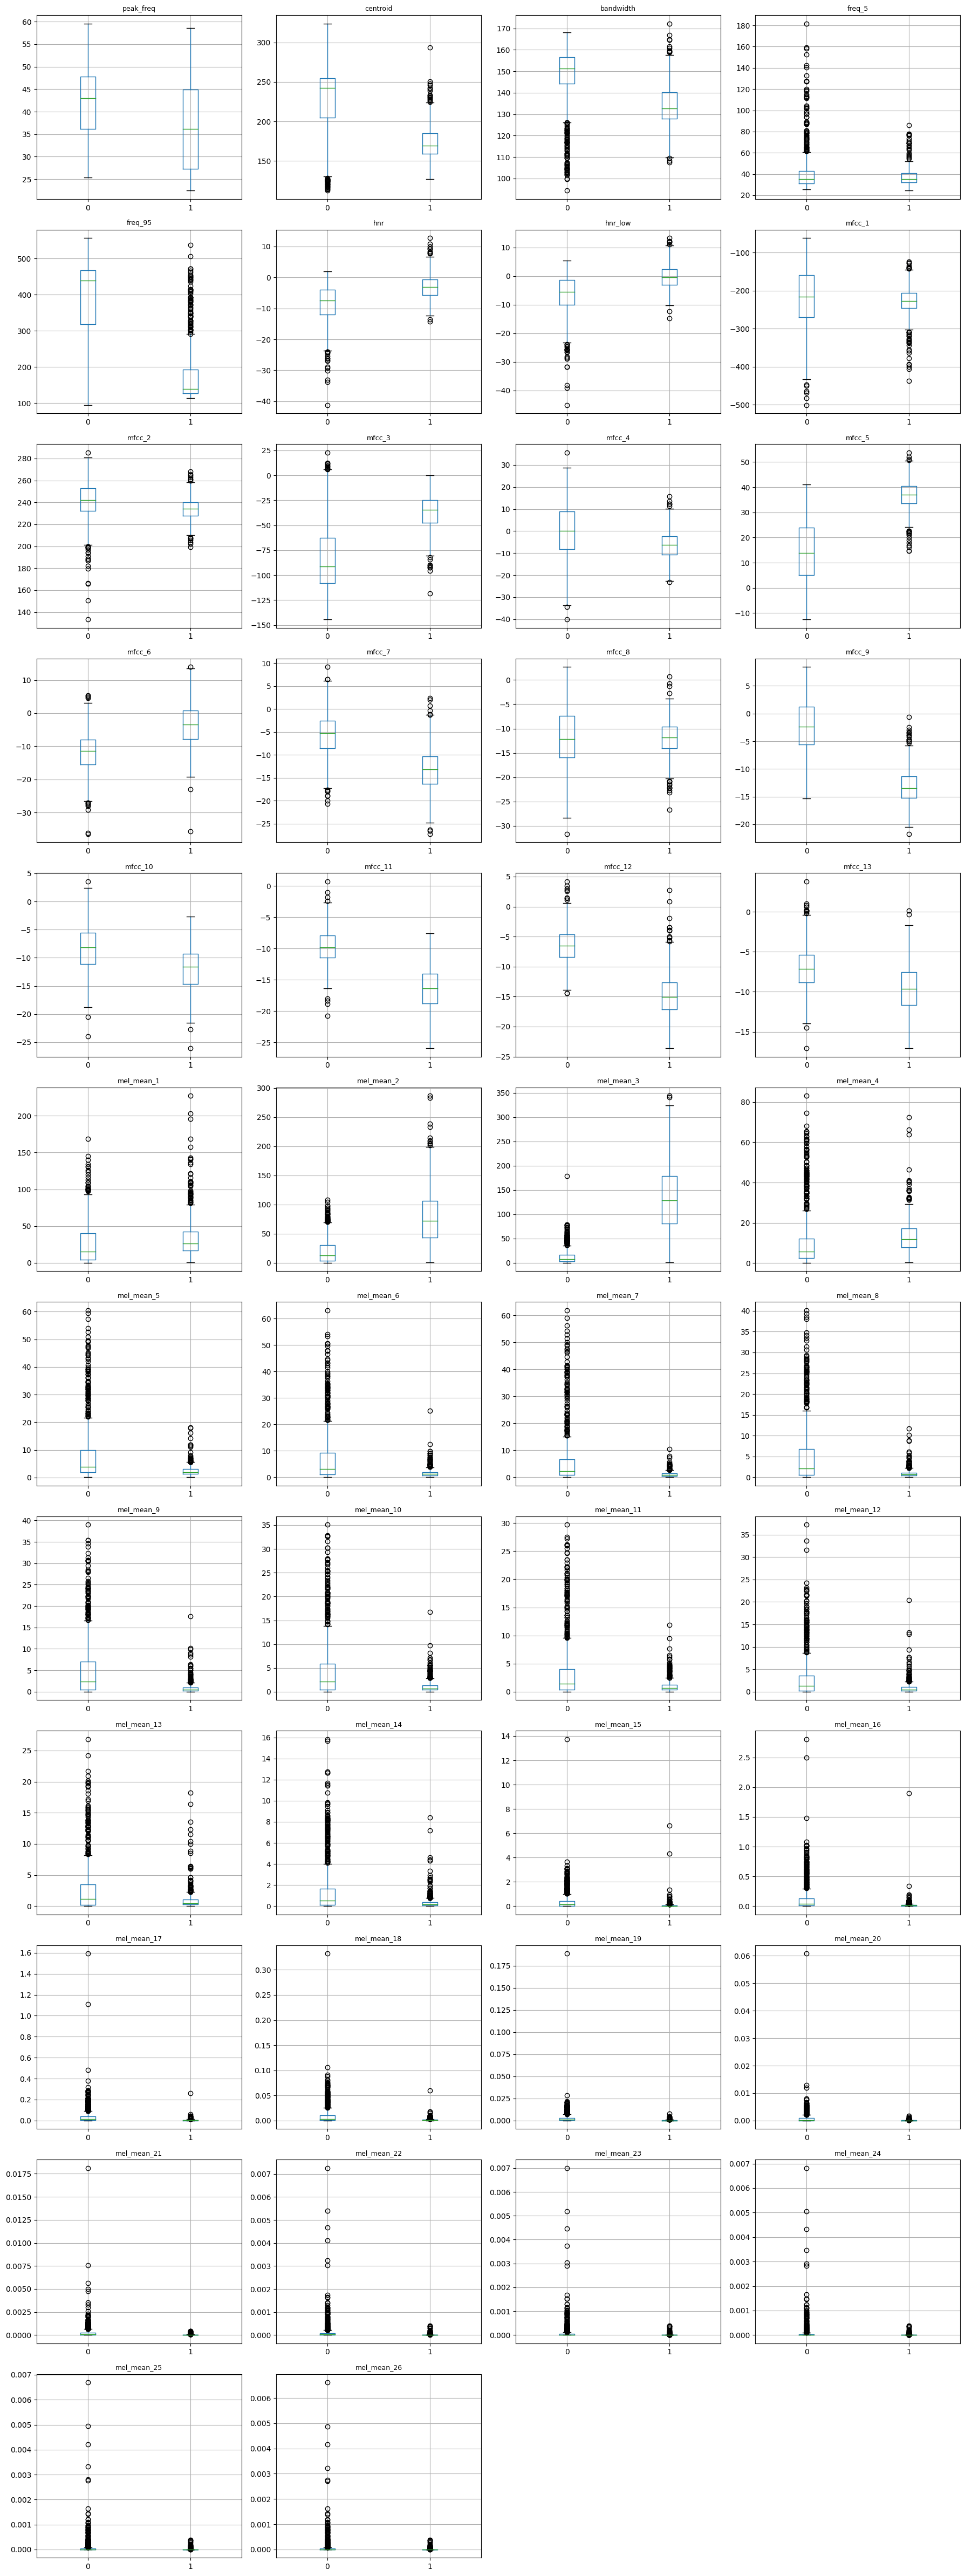

In [11]:
import matplotlib.pyplot as plt

# List of feature columns (everything except the label)
feature_cols = df.columns.drop("label")

# Determine the layout of the figure
n_features = len(feature_cols)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(feature_cols):

    df.boxplot(
        column=feature,
        by="label",
        ax=axes[i]
    )

    axes[i].set_title(feature, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("")
plt.tight_layout()

plt.show()

### Statistical Testing
Because our data does not follow a uniform distribution, we will use a **Mann-Whitney U test**

In [12]:
from scipy.stats import mannwhitneyu

In [13]:
# run the test on every feature
results = []

feature_cols = df.columns.drop("label")

for feature in feature_cols:

    background = df[df["label"] == 0][feature]
    rumble = df[df["label"] == 1][feature]

    stat, p = mannwhitneyu(
        background,
        rumble,
        alternative="two-sided"
    )

    results.append({
        "Feature": feature,
        "U Statistic": stat,
        "P Value": p
    })

results = pd.DataFrame(results)

In [14]:
# rank the features
results = results.sort_values("P Value")

results.head(20)

,Feature,U Statistic,P Value
15,mfcc_9,466405.0,1.024648e-200
22,mel_mean_3,15821.0,3.163536e-195
11,mfcc_5,19107.0,1.356942e-189
18,mfcc_12,457437.0,2.535457e-185
17,mfcc_11,453614.0,5.996701e-179
4,freq_95,437306.0,4.983857e-153
21,mel_mean_2,52471.0,4.098307e-137
13,mfcc_7,417755.0,1.217807e-124
9,mfcc_3,70201.0,1.033432e-112
1,centroid,404594.0,3.425283e-107


In [15]:
results["Significant"] = results["P Value"] < 0.05

results.head(20)

,Feature,U Statistic,P Value,Significant
15,mfcc_9,466405.0,1.024648e-200,True
22,mel_mean_3,15821.0,3.163536e-195,True
11,mfcc_5,19107.0,1.356942e-189,True
18,mfcc_12,457437.0,2.535457e-185,True
17,mfcc_11,453614.0,5.996701e-179,True
4,freq_95,437306.0,4.983857e-153,True
21,mel_mean_2,52471.0,4.098307e-137,True
13,mfcc_7,417755.0,1.217807e-124,True
9,mfcc_3,70201.0,1.033432e-112,True
1,centroid,404594.0,3.425283e-107,True


In [16]:
results["Significant"].value_counts()

Significant
True     45
False     1
Name: count, dtype: int64

In [17]:
results[results["Significant"] == False]

,Feature,U Statistic,P Value,Significant
14,mfcc_8,239155.0,0.959726,False


To reduce the chance of luck in our analysis, we will use a **Benjamini–Hochberg false discovery rate (FDR)** to adjust the p-va;ues

In [18]:
from statsmodels.stats.multitest import multipletests

results["Adjusted P"] = multipletests(
    results["P Value"],
    method="fdr_bh"
)[1]

results["Significant (FDR)"] = results["Adjusted P"] < 0.05

### Logistic Regression

In [19]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(1410, 46)
(353, 46)
label
0    839
1    571
Name: count, dtype: int64
label
0    219
1    134
Name: count, dtype: int64


In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [22]:
y_pred = model.predict(X_test_scaled)

### Classifier Evaluation

In [23]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[219   0]
 [  3 131]]


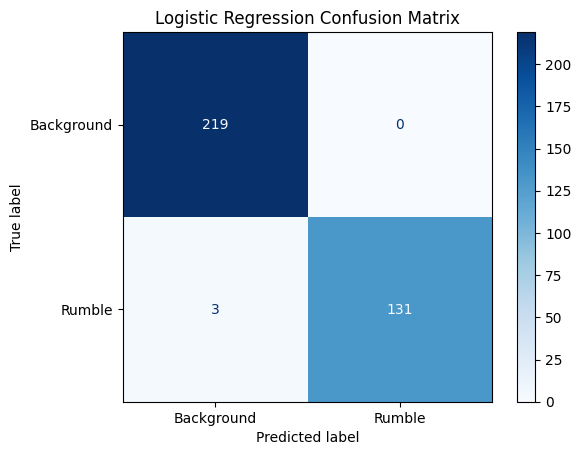

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Background", "Rumble"],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       219
           1       1.00      0.98      0.99       134

    accuracy                           0.99       353
   macro avg       0.99      0.99      0.99       353
weighted avg       0.99      0.99      0.99       353



In [26]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {auc:.3f}")

ROC-AUC: 1.000


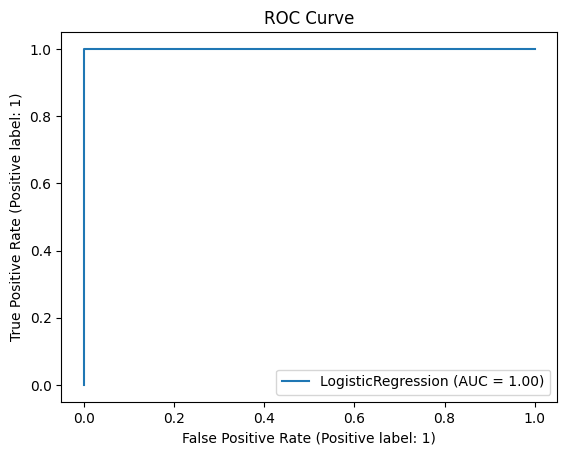

In [27]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    model,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve")
plt.show()

### Feature Importance from Logistic Regression

In [28]:
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute Coefficient",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient,Absolute Coefficient
6,hnr_low,1.896047,1.896047
11,mfcc_5,1.721328,1.721328
15,mfcc_9,-1.629240,1.629240
22,mel_mean_3,1.526876,1.526876
17,mfcc_11,-1.328778,1.328778
31,mel_mean_12,-1.241665,1.241665
5,hnr,1.223403,1.223403
2,bandwidth,1.097552,1.097552
13,mfcc_7,-1.072653,1.072653
3,freq_5,-0.966819,0.966819


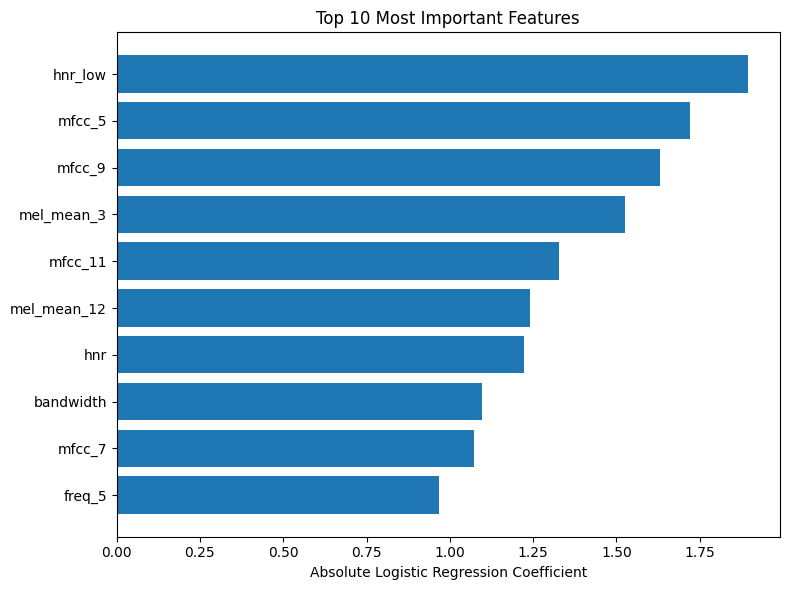

In [29]:
import matplotlib.pyplot as plt

top10 = coefficients.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Absolute Coefficient"]
)

plt.xlabel("Absolute Logistic Regression Coefficient")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [30]:
feature_summary = coefficients.merge(
    results,
    on="Feature"
)

feature_summary = feature_summary.sort_values(
    "Absolute Coefficient",
    ascending=False
)

feature_summary.head(10)

,Feature,Coefficient,Absolute Coefficient,U Statistic,P Value,Significant,Adjusted P,Significant (FDR)
0,hnr_low,1.896047,1.896047,103759.0,3.794032e-73,True,1.342504e-72,True
1,mfcc_5,1.721328,1.721328,19107.0,1.356942e-189,True,2.080644e-188,True
2,mfcc_9,-1.629240,1.629240,466405.0,1.024648e-200,True,4.713383e-199,True
3,mel_mean_3,1.526876,1.526876,15821.0,3.163536e-195,True,7.276132e-194,True
4,mfcc_11,-1.328778,1.328778,453614.0,5.996701e-179,True,5.516965e-178,True
5,mel_mean_12,-1.241665,1.241665,309070.0,1.956195e-20,True,2.249624e-20,True
6,hnr,1.223403,1.223403,117885.0,4.408133e-59,True,1.267338e-58,True
7,bandwidth,1.097552,1.097552,395776.0,3.021093e-96,True,1.158086e-95,True
8,mfcc_7,-1.072653,1.072653,417755.0,1.217807e-124,True,7.002389e-124,True
9,freq_5,-0.966819,0.966819,256749.5,2.164094e-02,True,2.212185e-02,True


### Cross Validation with Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier

In [32]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [33]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [34]:
rf_pred = rf_model.predict(X_test)

In [35]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       219
           1       1.00      0.98      0.99       134

    accuracy                           0.99       353
   macro avg       0.99      0.99      0.99       353
weighted avg       0.99      0.99      0.99       353



### RandomForest Feature Importance

In [36]:
import pandas as pd

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance.head(15)

,Feature,Importance
22,mel_mean_3,0.149013
18,mfcc_12,0.128015
15,mfcc_9,0.124357
11,mfcc_5,0.104799
17,mfcc_11,0.089894
4,freq_95,0.043499
6,hnr_low,0.038123
9,mfcc_3,0.034127
21,mel_mean_2,0.033004
1,centroid,0.029606


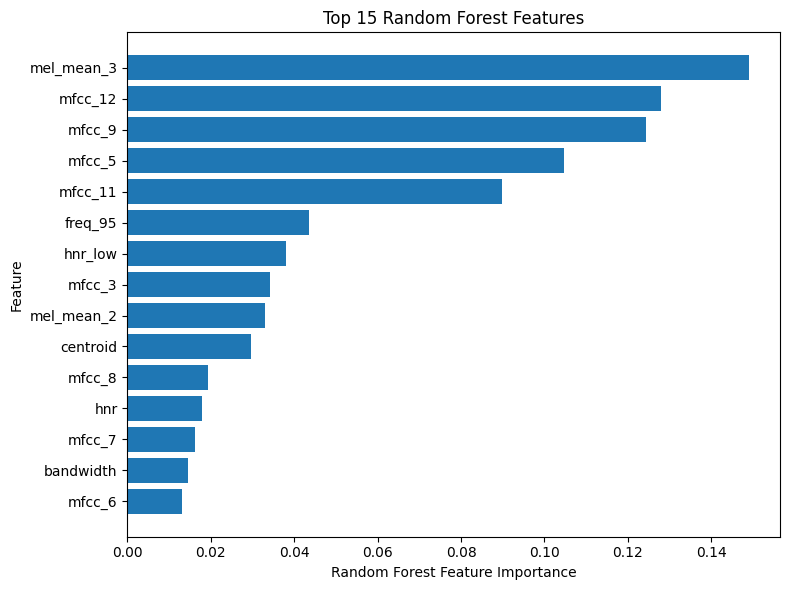

In [37]:
import matplotlib.pyplot as plt

top15 = rf_importance.head(15)

plt.figure(figsize=(8,6))

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [38]:
# Mann-Whitney U ranking
mw_rank = results.copy()

mw_rank = mw_rank.sort_values("P Value")

mw_rank["MW Rank"] = range(1, len(mw_rank)+1)

mw_rank = mw_rank[[
    "Feature",
    "MW Rank",
    "P Value"
]]

# Logistic Regression ranking
lr_rank = coefficients.copy()

lr_rank = lr_rank.sort_values(
    "Absolute Coefficient",
    ascending=False
)

lr_rank["LR Rank"] = range(1, len(lr_rank)+1)

lr_rank = lr_rank[[
    "Feature",
    "Coefficient",
    "Absolute Coefficient",
    "LR Rank"
]]

# Random Forest ranking
rf_rank = rf_importance.copy()

rf_rank = rf_rank.sort_values(
    "Importance",
    ascending=False
)

rf_rank["RF Rank"] = range(1, len(rf_rank)+1)

rf_rank = rf_rank[[
    "Feature",
    "Importance",
    "RF Rank"
]]

# merge
comparison = (
    mw_rank
    .merge(lr_rank, on="Feature")
    .merge(rf_rank, on="Feature")
)

# add overall ranking
comparison["Average Rank"] = (
    comparison["MW Rank"] +
    comparison["LR Rank"] +
    comparison["RF Rank"]
) / 3
comparison = comparison.sort_values("Average Rank")
comparison = comparison[[
    "Feature",
    "P Value",
    "Coefficient",
    "Importance",
    "MW Rank",
    "LR Rank",
    "RF Rank",
    "Average Rank"
]]

comparison.head(20)

,Feature,P Value,Coefficient,Importance,MW Rank,LR Rank,RF Rank,Average Rank
0,mfcc_9,1.024648e-200,-1.629240,0.124357,1,3,3,2.333333
1,mel_mean_3,3.163536e-195,1.526876,0.149013,2,4,1,2.333333
2,mfcc_5,1.356942e-189,1.721328,0.104799,3,2,4,3.000000
4,mfcc_11,5.996701e-179,-1.328778,0.089894,5,5,5,5.000000
3,mfcc_12,2.535457e-185,-0.866213,0.128015,4,12,2,6.000000
12,hnr_low,3.794032e-73,1.896047,0.038123,13,1,7,7.000000
5,freq_95,4.983857e-153,-0.751995,0.043499,6,13,6,8.333333
7,mfcc_7,1.217807e-124,-1.072653,0.016253,8,9,13,10.000000
11,bandwidth,3.021093e-96,1.097552,0.014489,12,8,14,11.333333
15,hnr,4.408133e-59,1.223403,0.017863,16,7,12,11.666667
